# CALIFORNIA HOUSING

En este notebook, se prodederá al análisis y tratamiento de datos de casas de California (California Housing dataset) con el fin de crear modelos de IA para predecir el precio de una vivienda a partir de variables relevantes

## Índice de los contenidos
- Importación de los datos
- Visualización de los datos (antes del procesamiento)
- Creación de los conjuntos de 'train', 'validation' y 'test'
- Eliminación de outliers en el conjunto de 'train'
- Normalización de los datos
- Aplicación del modelo de Regresión Lineal
- TO DO
- Créditos

# Importación de los datos
Importación del dataset y lectura de sus características

In [1]:
import pandas as pd

DATOS = pd.read_csv("housing.csv")

### Descripción de las variables
1. **longitude:** A measure of how far west a house is; a higher value is farther west

2. **latitude:** A measure of how far north a house is; a higher value is farther north

3. **housingMedianAge:** Median age of a house within a block; a lower number is a newer building

4. **totalRooms:** Total number of rooms within a block

5. **totalBedrooms:** Total number of bedrooms within a block

6. **population:** Total number of people residing within a block

7. **households:** Total number of households (hogares, viviendas, domicilios), a group of people residing within a home unit, for a block

8. **medianIncome:** Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. **medianHouseValue:** Median house value for households within a block (measured in US Dollars)

10. **oceanProximity:** Location of the house w.r.t ocean/sea

In [2]:
DATOS.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
DATOS.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
DATOS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
DATOS.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
# 2 opciones: Eliminar los valores nulos o replazarlos con la media
data_non_null = DATOS.dropna()
data_non_null.info()

data_clean = DATOS.copy()
data_clean["total_bedrooms"] = data_clean["total_bedrooms"].fillna(value=data_clean["total_bedrooms"].mean())

#  Imprimimos para ver si la media cambia:
# Parece que 'total_bedrooms' no cambia (Si cambias los datos nulos por la media no alteras la media global)
# Pero otros valores si pueden cambiar (Si eliminas datos con 'total_bedrooms' nulos, realmente estás borrando
# esa fila de datos entera, por lo que eliminas ese valor del conteo de la media)
print("\ntotal_bedrooms:")
print(f"Media sin valores nulos:  {data_non_null["total_bedrooms"].mean()}")
print(f"Media imputando la media: {data_clean["total_bedrooms"].mean()}")

print("\nhousing_median_age:")
print(f"Media sin valores nulos:  {data_non_null["housing_median_age"].mean()}")
print(f"Media imputando la media: {data_clean["housing_median_age"].mean()}")

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB

total_bedrooms:
Media sin valores nulos:  537.8705525375618
Media imputando la media: 537.8705525375617

housing_median_age:
Media sin valores nulos:  28.633093525179856
Media imputando la media: 28.639486434108527


In [7]:
# Elijo quedarme con el dataframe sin datos nulos (y sin imputación de datos)
data = data_non_null.copy()

# Visualización de los datos (antes del procesamiento)
Mediante matplotlib y pandas

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Para ver boxplots de cada serie de datos numéricos
def plotBoxplots(data, figsize=(16, 6)):
    """
    Muestra un boxplot para cada valor numérico de 'data'
    """

    # Creamos los ejes de la figura
    plot_data = data.select_dtypes(include="number")
    rows = 2
    cols = (len(plot_data.columns) + 1) // rows

    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=figsize, layout="constrained")
    # Aplanamos la matriz para recorrer cada uno de sus valores (no nos interesan sus índices x,y)
    axs = axs.flatten()

    for i, col in enumerate(plot_data.columns):
        ax = axs[i]
        ax.set_title(col)
        data = np.array(plot_data[col])
        ax.boxplot(data, showmeans=True, showfliers=True)

    # Ocultamos las celdas vacías (si las hay)
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    plt.show()


# Para ver bar plots de cada serie de datos numéricos
def plotBarPlots(data, figsize=(16, 6)):
    """
    Muestra un boxplot para cada valor numérico de 'data'
    """

    # Creamos los ejes de la figura
    plot_data = data.select_dtypes(include="number")
    rows = 2
    cols = (len(plot_data.columns) + 1) // rows

    fig, axs = plt.subplots(
        nrows=rows, ncols=cols, figsize=figsize, layout="constrained"
    )
    # Aplanamos la matriz para recorrer cada uno de sus valores (no nos interesan sus índices x,y)
    axs = axs.flatten()

    for i, col in enumerate(plot_data.columns):
        ax = axs[i]
        ax.set_title(col)
        data = np.array(plot_data[col])
        ax.hist(data, bins=50, edgecolor="white")

    # Ocultamos las celdas vacías (si las hay)
    for j in range(i + 1, len(axs)):
        axs[j].set_visible(False)

    plt.show()

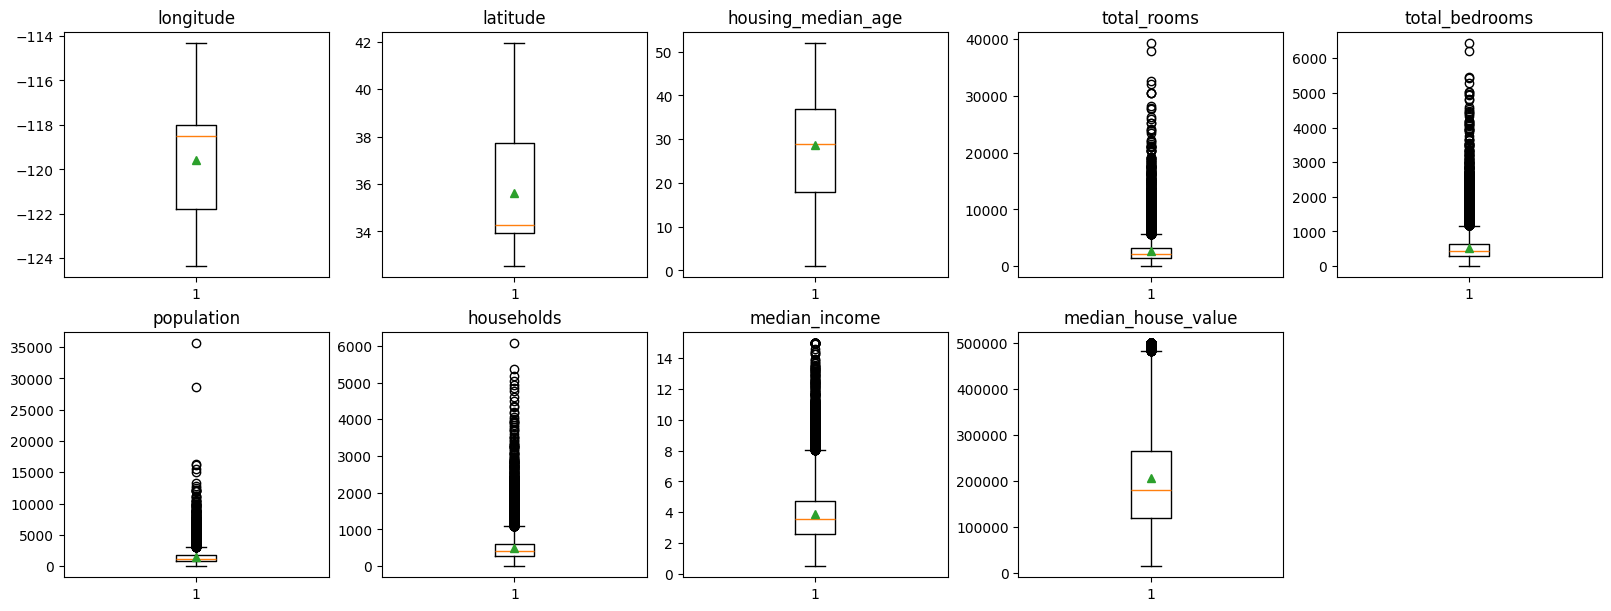

In [9]:
plotBoxplots(data)
# plotBarPlots(data)

# Creación de los conjuntos de train, validation y test


In [10]:
trainingNum = 0.8
validationNum = 0.1
train_index = int(len(data) * trainingNum)
validation_index = int(len(data) * validationNum)

# Dividimos 'data' en tres conjuntos
train = data[:train_index].copy()
validation = data[train_index : train_index + validation_index].copy()
test = data[train_index + validation_index :].copy()

print("Lengths:", train.shape, validation.shape, test.shape)

Lengths: (16346, 10) (2043, 10) (2044, 10)


# Eliminación de outliers de todas las variables (en el set 'train')
Primero, creamos nuevas columnas con las variables relativas a 'household'. Por ejemplo, en un bloque de casas con 500 habitaciones es importante conocer si hay 500 residentes/habitantes o 1000

Después, para cada variable numérica, miramos cada uno de sus valores y eliminamos los que estén por muy alejados de la media (1.5 * RangoIntercuartil)

### Creación de columnas con valores relativos
Las columnas 'total_rooms', 'total_bedrooms' y 'population' dependen del número total de 'households' (apartamentos, viviendas) de cada bloque

Esto se hace en cada set de datos aunque no se vayan a alterar datos de 'validation' y 'test' (para mantener las mismas dimensiones)

In [11]:
# 'total_rooms', 'total_bedrooms' y 'population' relativo a 'households'
train["rooms_per_household"] = train["total_rooms"] / train["households"]
train["bedrooms_per_household"] = train["total_bedrooms"] / train["households"]
train["population_per_household"] = train["population"] / train["households"]
train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_household,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,1.023810,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.971880,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,1.073446,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,1.073059,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,1.081081,2.181467


In [12]:
# Lo mismo para 'validation' y 'test'
validation["rooms_per_household"] = validation["total_rooms"] / validation["households"]
validation["bedrooms_per_household"] = (
    validation["total_bedrooms"] / validation["households"]
)
validation["population_per_household"] = (
    validation["population"] / validation["households"]
)

test["rooms_per_household"] = test["total_rooms"] / test["households"]
test["bedrooms_per_household"] = test["total_bedrooms"] / test["households"]
test["population_per_household"] = test["population"] / test["households"]

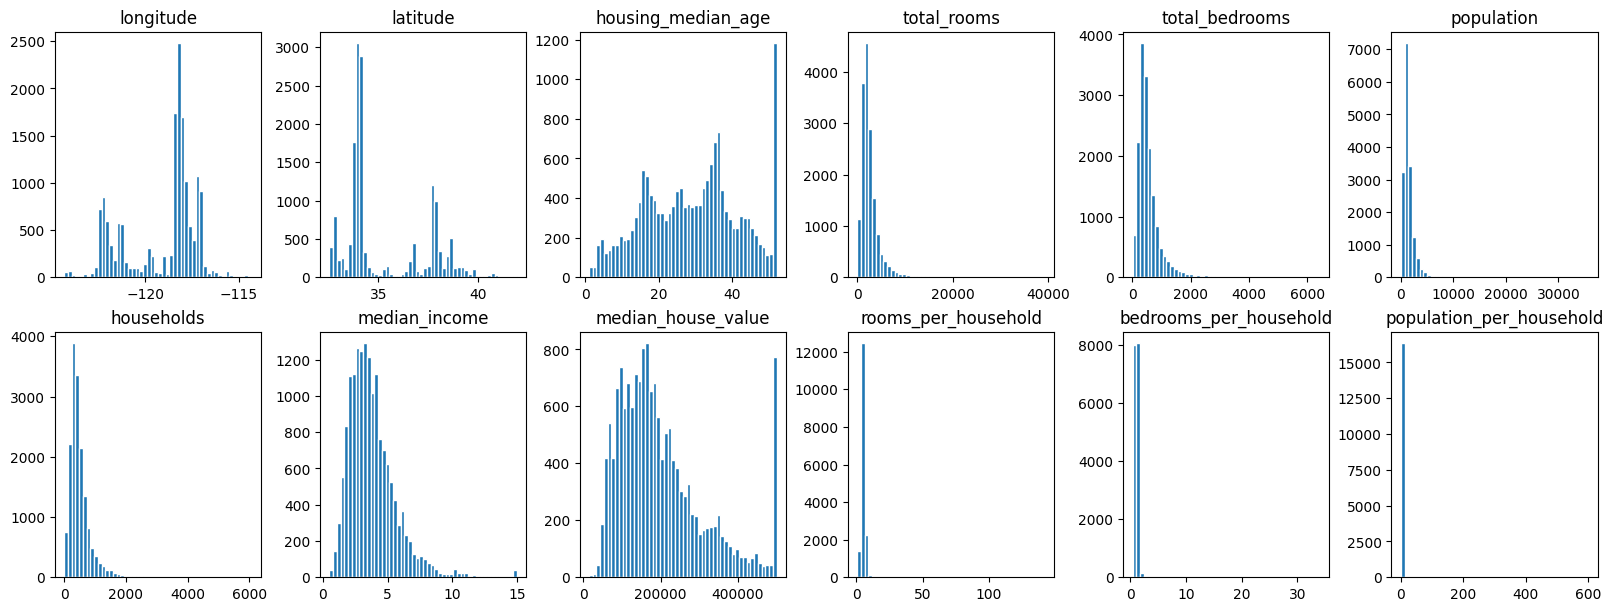

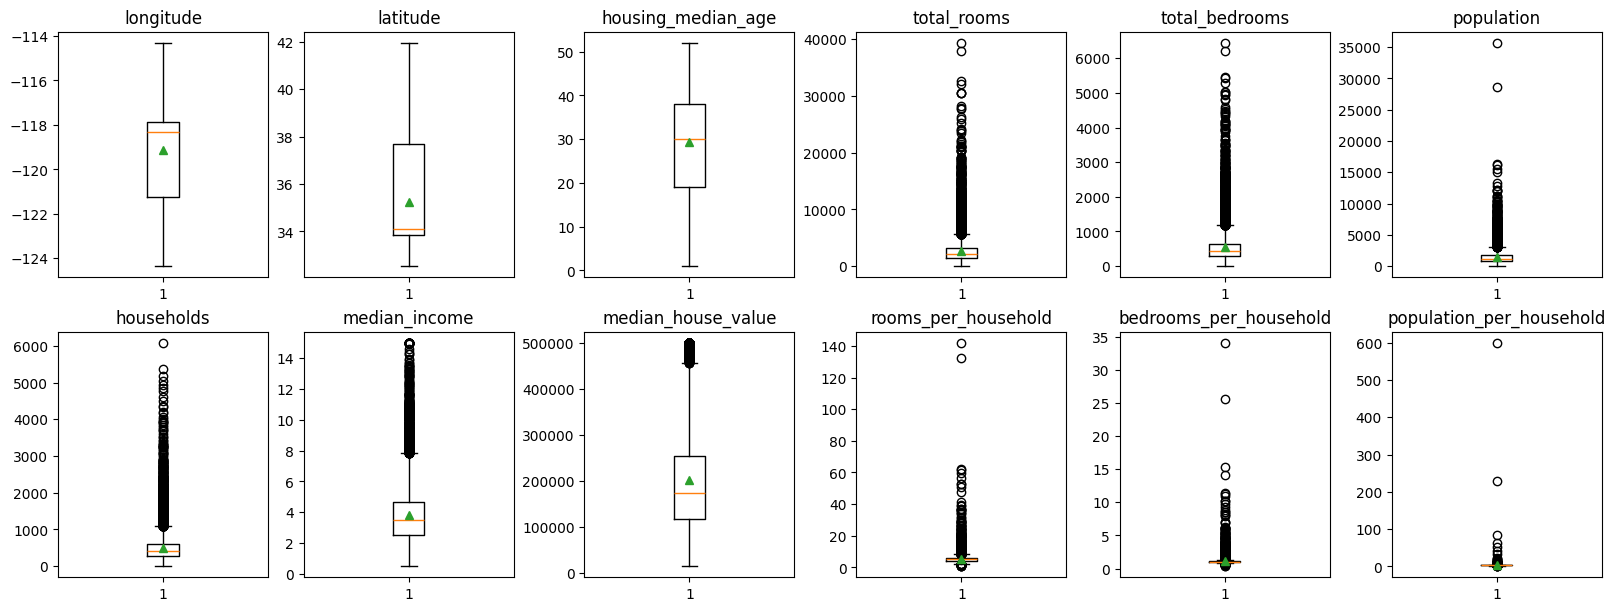

In [13]:
# Ahora ya podemos ver mejor las variables
plotBarPlots(train)
plotBoxplots(train)

### Eliminación de datos fuera de rango
Primero, quitamos las casas con 'median_house_value' igual a 500001 y las casas con 'housing_median_age' iguales a 52 (son valores mal etiquetados, están aproximados a ese valor como 'valor máximo')

Luego, eliminamos outliers de las variables relativas

Valores eliminados y su frecuencia
Valor: 500001.0		Frecuencia:719


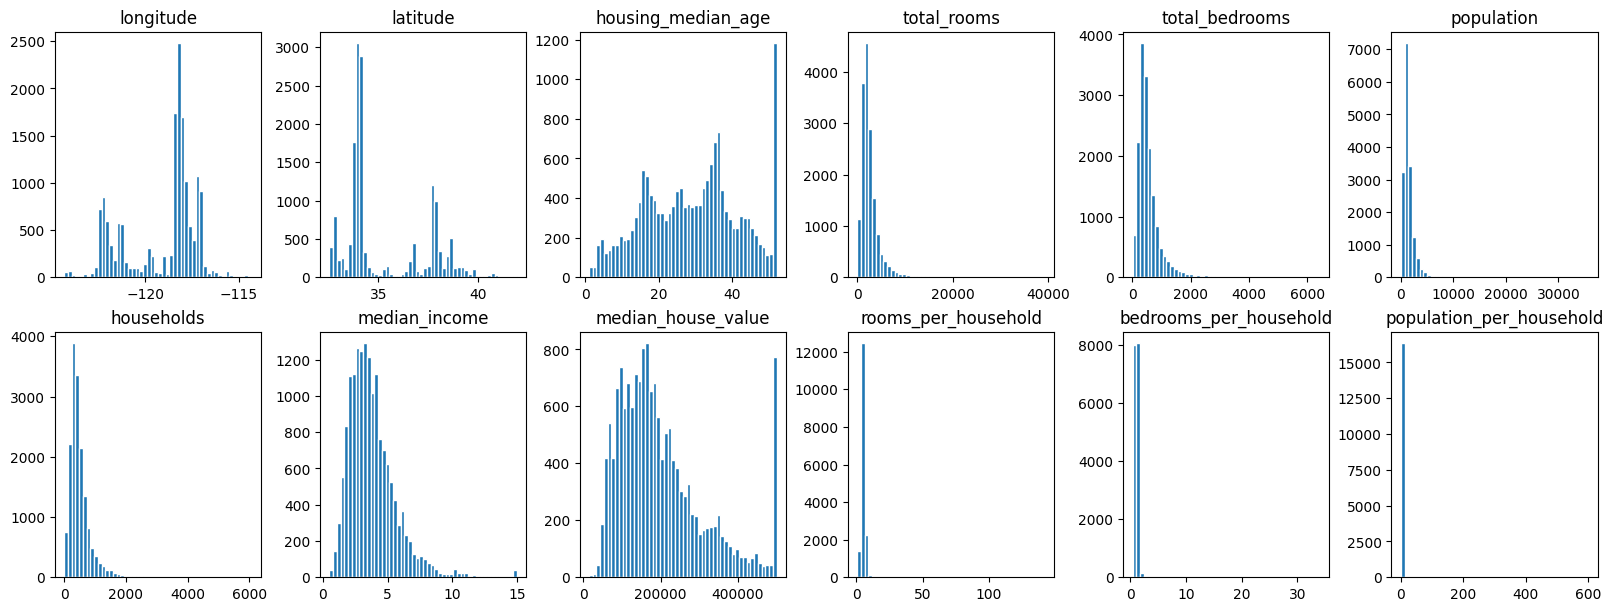

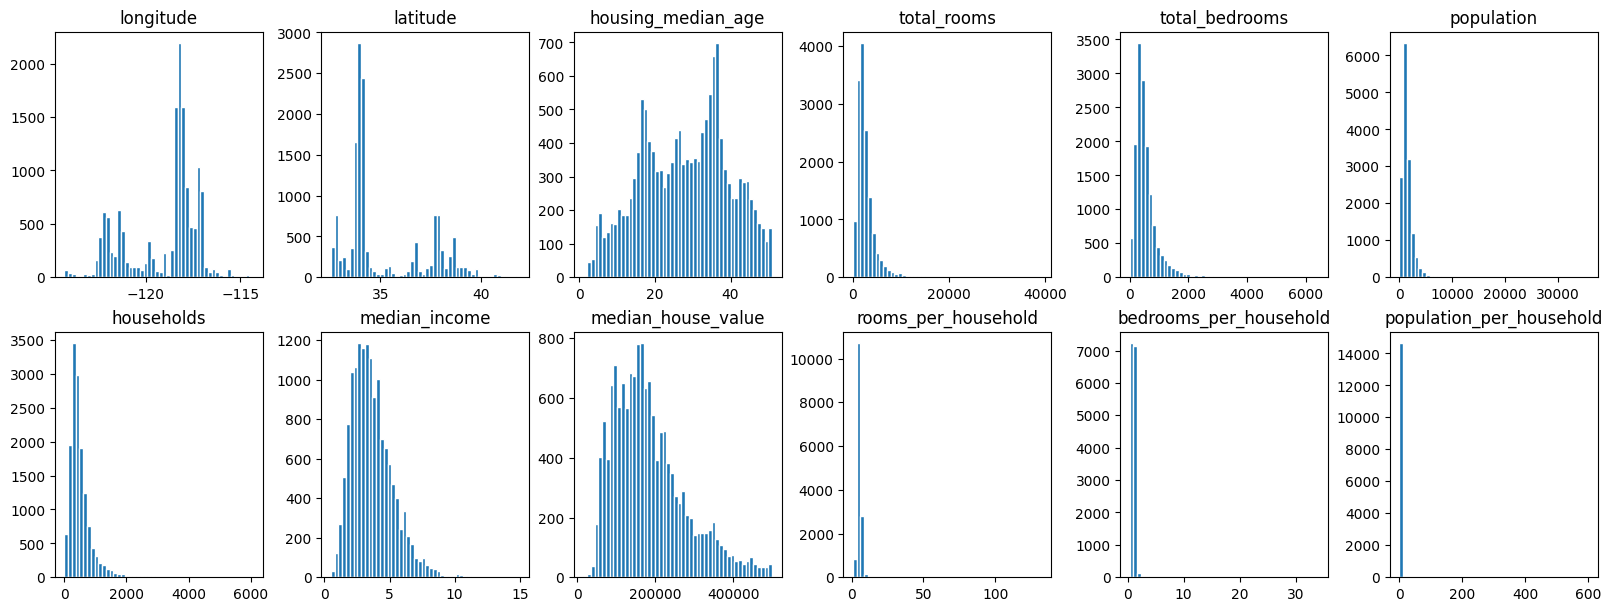

In [14]:
# --- Quitamos las casas con 'median_house_value' igual a 500001 y las casas con 'median_house_age' iguales a 52 --
trainValoresCorregidos = train.copy()

"""
TO DO: También se puede implementar una función (o buscar un método de pandas) que elimine valores por encima de
una frecuencia especificada (ej, eliminar todos los valores con frecuencia >= 100)
"""

# Eliminamos los 'n' datos con una frecuencia alta en la columna 'median_house_value'
# a partir de un pandas.Series que indica la frecuencia de cada dato
n = 1  # Eliminar 1, 2, 5, etc. valores (Mínimo uno, ya que las casas de valor 500000.1 están mal etiquetadas)
dataSeries = trainValoresCorregidos["median_house_value"].value_counts()
freq = trainValoresCorregidos["median_house_value"].value_counts().values.tolist()

# Como los datos están ordenados de mayor a menor frecuencia por defecto,
# simplemente eliminamos los primeros 'n' de la lista
print("Valores eliminados y su frecuencia")
for i in range(n):
    frecuencia = freq[i]
    # El valor con esa frecuencia se encuentra en ese dataSeries de esta manera
    # Como 'dataSeries[dataSeries == frecuencia]' devuelve otra dataSeries, lo transformamos
    # a una lista/array y cogemos el primer (y único) elemento
    valor = dataSeries[dataSeries == frecuencia].index.tolist()[0]
    # Imprime la frecuencia con la que se repite el valor y dicho valor
    print(f"Valor: {valor}\t\tFrecuencia:{frecuencia}")
    # Para eliminar los valores, solo guardamos los valores distintos a 'valor'
    trainValoresCorregidos = trainValoresCorregidos[
        trainValoresCorregidos.median_house_value != valor
    ]


trainValoresCorregidos = trainValoresCorregidos[
    trainValoresCorregidos.housing_median_age != 52
]
plotBarPlots(train)
plotBarPlots(trainValoresCorregidos)

<Axes: xlabel='median_house_value', ylabel='median_income'>

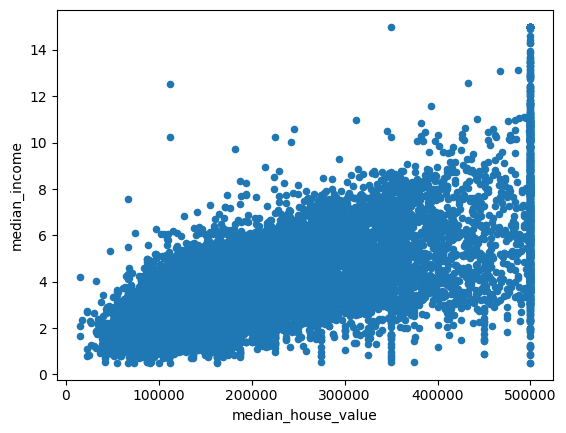

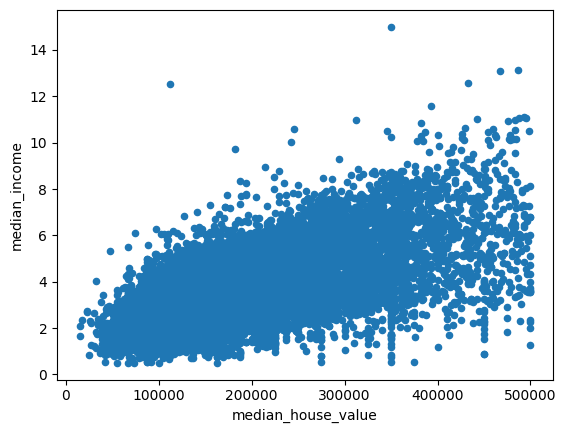

In [15]:
# Comprobamos que se hayan eliminados esas líneas verticales
train.plot.scatter(x="median_house_value", y="median_income")
trainValoresCorregidos.plot.scatter(x="median_house_value", y="median_income")

In [16]:
# --- Eliminación de outliers ---
# A partir de las nuevas variables relativas, se eliminan los valores muy alejados de la media

separacion_maxima = 1.5  # 2.5 también sirve
train_sin_outliers = trainValoresCorregidos.copy()

# Solo nos interesan las variables numéricas, no categóricas
variables_numericas = train_sin_outliers.select_dtypes(include="number")
print(list(variables_numericas.columns))

print(" COLUMN NAME  |  Q1  |  Q3  |  RI")
for col in variables_numericas.columns:
    columnName = variables_numericas[col]
    # print("\n", col, "\n", column)

    # IQR o RI: Rango intercuartil
    Q1, Q3 = variables_numericas[col].quantile([0.25, 0.75])
    RI = Q3 - Q1
    print(col, "\t", Q1, "\t", Q3, "\t", RI)

    # Eliminamos los outliers por encima del valor especificado
    """ train_limpio = train[(train["columna"] >= Q1 - 1.5 * RI) & (train["columna"] <= Q3 + 1.5 * RI)] """
    train_sin_outliers = train_sin_outliers[
        (train_sin_outliers[col] >= Q1 - separacion_maxima * RI)
        & (train_sin_outliers[col] <= Q3 + separacion_maxima * RI)
    ]

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_household', 'population_per_household']
 COLUMN NAME  |  Q1  |  Q3  |  RI
longitude 	 -120.795 	 -117.85 	 2.9450000000000074
latitude 	 33.85 	 37.51 	 3.6599999999999966
housing_median_age 	 18.0 	 36.0 	 18.0
total_rooms 	 1446.0 	 3144.0 	 1698.0
total_bedrooms 	 300.0 	 660.0 	 360.0
population 	 817.0 	 1783.0 	 966.0
households 	 284.0 	 614.0 	 330.0
median_income 	 2.4930000000000003 	 4.5275 	 2.0344999999999995
median_house_value 	 114000.0 	 231900.0 	 117900.0
rooms_per_household 	 4.366112538023601 	 5.954376028657179 	 1.5882634906335777
bedrooms_per_household 	 1.0067819607662765 	 1.1007394346946586 	 0.09395747392838216
population_per_household 	 2.4702836499866203 	 3.35656836461126 	 0.8862847146246398


In [17]:
print("Ver si queremos trabajar con 'train' 'trainValoresCorregidos' o 'train_sin_outliers'")
# a = 2 / 0

Ver si queremos trabajar con 'train' 'trainValoresCorregidos' o 'train_sin_outliers'


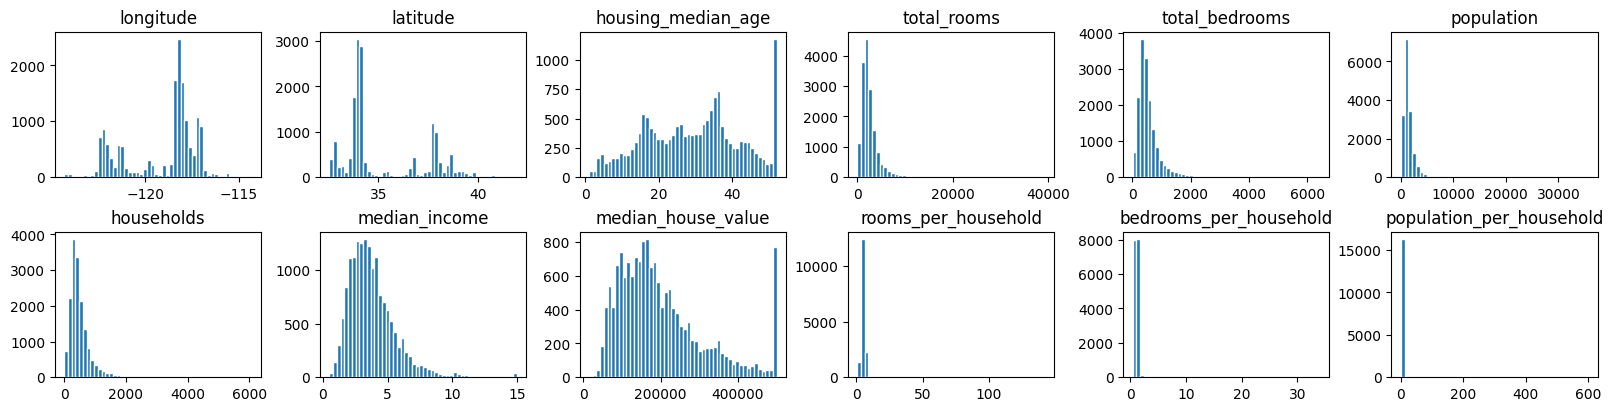

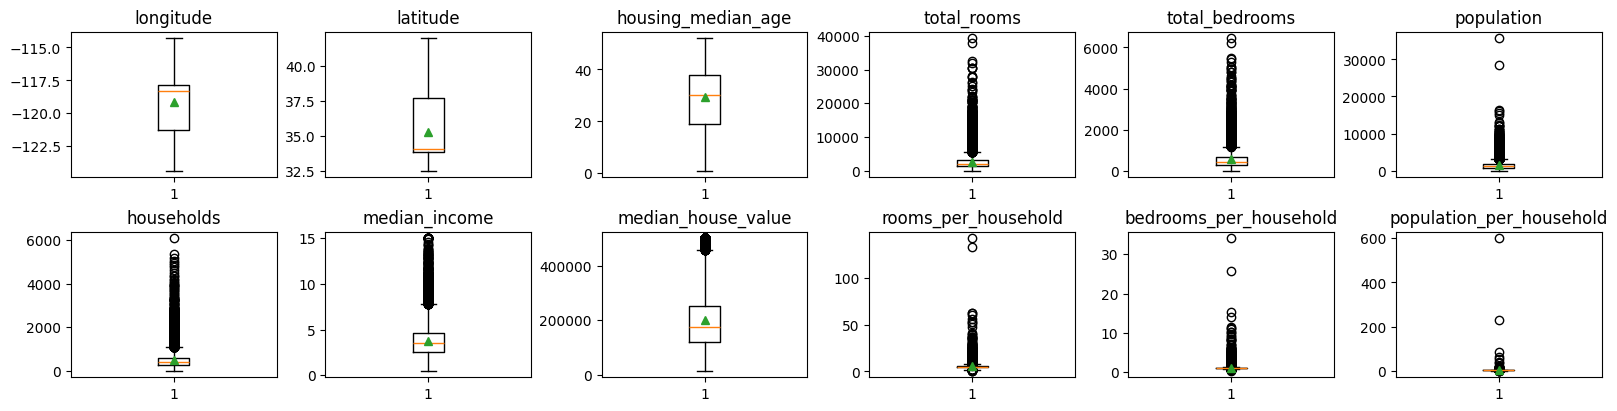


DATOS SIN OUTLIERS


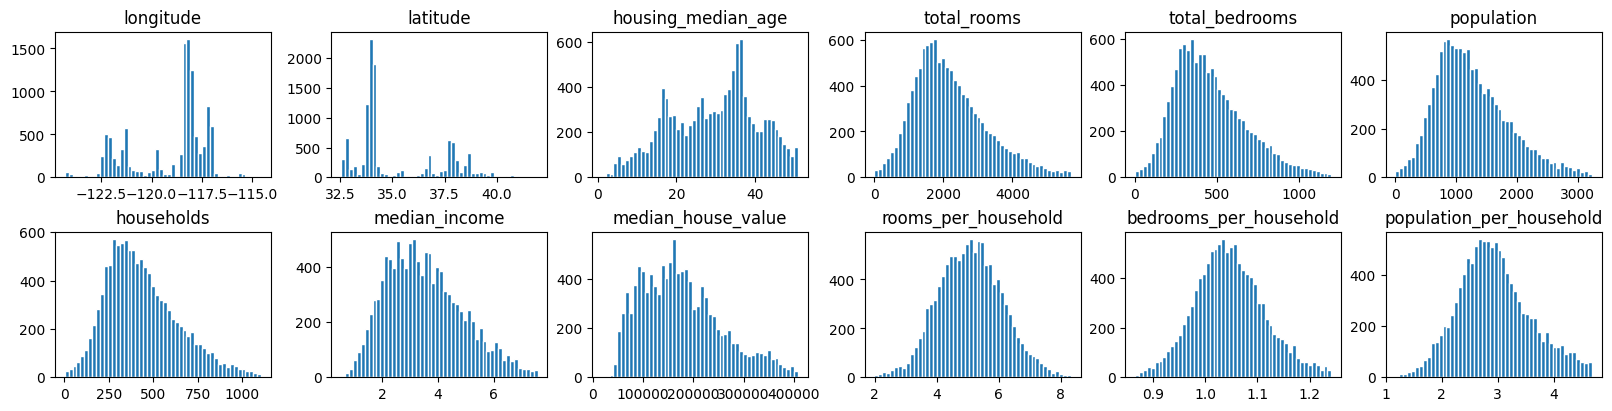

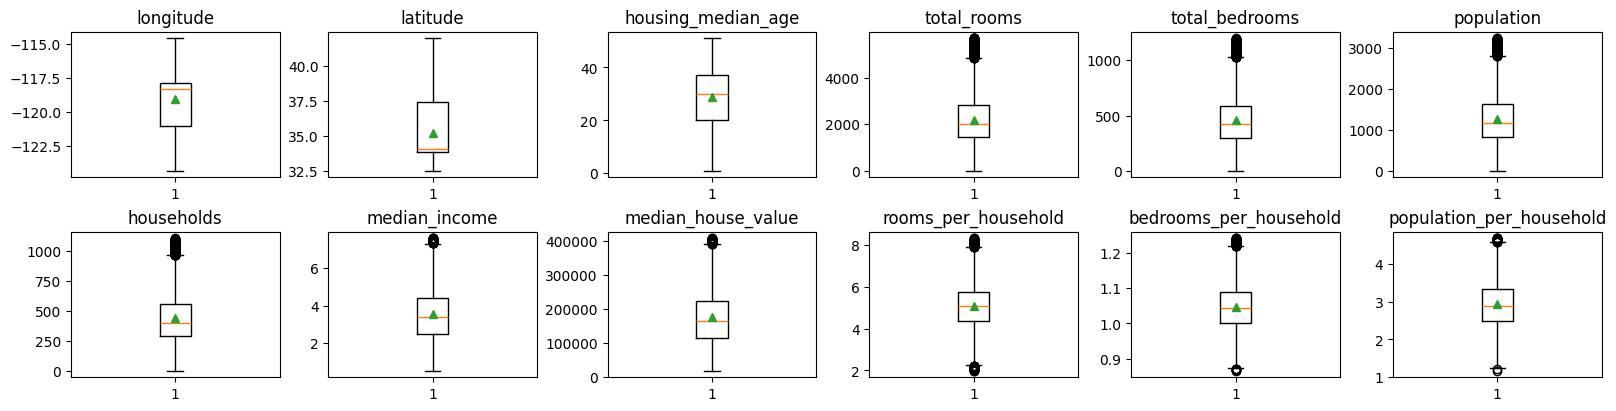

In [18]:
# Volvemos a visualizar los datos
plotBarPlots(train, figsize=(16, 4))
plotBoxplots(train, figsize=(16, 4))
print("\nDATOS SIN OUTLIERS")
plotBarPlots(train_sin_outliers, figsize=(16, 4))
plotBoxplots(train_sin_outliers, figsize=(16, 4))

In [19]:
# Volvemos a guardar los nuevos datos como 'train'
train = train_sin_outliers.copy()
train.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_household,population_per_household
count,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000
mean,-119.061954,35.191351,28.938590,2197.903460,460.037670,1263.434078,437.752694,3.530914,176078.335523,5.083730,1.047129,2.945549
std,1.862493,2.077002,11.153979,1059.168899,219.197381,596.388440,202.939161,1.370927,80103.563624,1.030778,0.067185,0.650299
min,-124.300000,32.540000,1.000000,6.000000,2.000000,5.000000,2.000000,0.536000,17500.000000,1.985337,0.866029,1.169329
25%,-121.020000,33.860000,20.000000,1441.000000,298.000000,825.500000,288.500000,2.488250,112850.000000,4.359988,1.002186,2.496030
50%,-118.270000,34.080000,30.000000,2013.000000,423.000000,1167.000000,404.000000,3.368700,165000.000000,5.074866,1.043534,2.886179
75%,-117.890000,37.440000,37.000000,2807.000000,590.000000,1618.000000,559.000000,4.412500,224700.000000,5.775489,1.089265,3.336303
max,-114.570000,41.950000,51.000000,5690.000000,1199.000000,3232.000000,1107.000000,7.579100,408500.000000,8.332326,1.241525,4.685897


In [20]:
train.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_household,population_per_household
longitude,1.000000,-0.945272,-0.066957,0.017337,0.061611,0.133771,0.063587,0.045784,0.090456,-0.106819,-0.024986,0.172283
latitude,-0.945272,1.000000,-0.030392,0.000349,-0.066566,-0.136594,-0.071810,-0.096406,-0.239562,0.162724,0.052143,-0.165051
housing_median_age,-0.066957,-0.030392,1.000000,-0.321401,-0.252137,-0.197985,-0.244754,-0.188815,0.032838,-0.208143,-0.098754,0.083740
total_rooms,0.017337,0.000349,-0.321401,1.000000,0.875319,0.780803,0.887692,0.264971,0.184933,0.295913,0.093433,-0.176440
total_bedrooms,0.061611,-0.066566,-0.252137,0.875319,1.000000,0.852408,0.991473,-0.068207,0.081022,-0.135316,0.235641,-0.204140
population,0.133771,-0.136594,-0.197985,0.780803,0.852408,1.000000,0.866604,-0.054846,-0.028369,-0.114597,0.074604,0.270163
households,0.063587,-0.071810,-0.244754,0.887692,0.991473,0.866604,1.000000,-0.034354,0.096637,-0.131536,0.121337,-0.196939
median_income,0.045784,-0.096406,-0.188815,0.264971,-0.068207,-0.054846,-0.034354,1.000000,0.627731,0.704717,-0.264880,-0.080814
median_house_value,0.090456,-0.239562,0.032838,0.184933,0.081022,-0.028369,0.096637,0.627731,1.000000,0.256458,-0.108366,-0.264906
rooms_per_household,-0.106819,0.162724,-0.208143,0.295913,-0.135316,-0.114597,-0.131536,0.704717,0.256458,1.000000,-0.000687,-0.023181


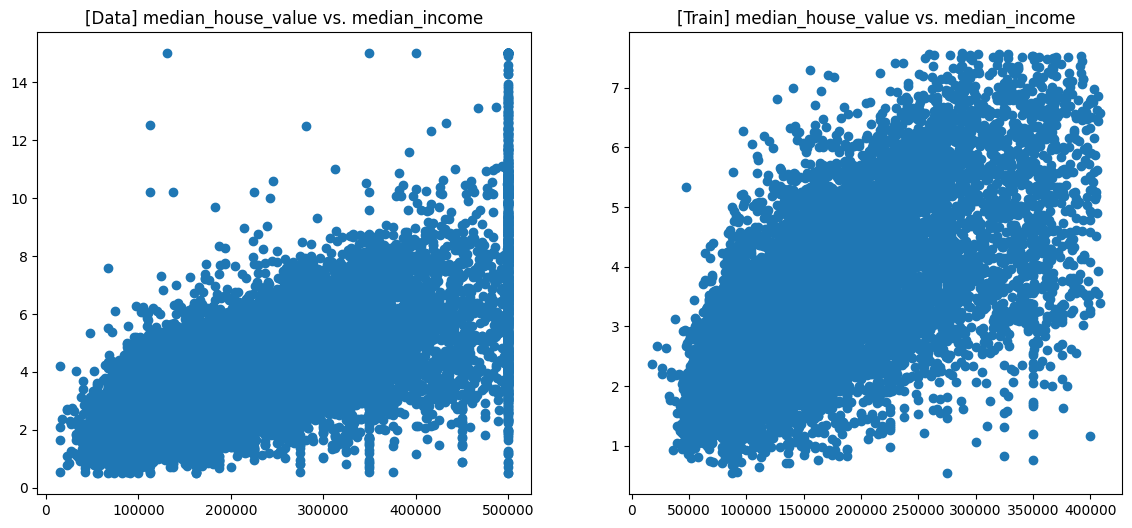

In [21]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

x = data["median_house_value"]
y = data["median_income"]
ax1.set_title("[Data] median_house_value vs. median_income")
ax1.scatter(x, y)

x = train["median_house_value"]
y = train["median_income"]
ax2.set_title("[Train] median_house_value vs. median_income")
ax2.scatter(x, y)
plt.show()

In [22]:
# Resumen de los datos que tenemos y el procesados que se ha hecho

print("Lengths:", train.shape, validation.shape, test.shape)
print("Data:", data.shape)

valoresEliminados = data.shape[0] - (train.shape[0] + validation.shape[0] + test.shape[0])
print("Valores eliminados: ", valoresEliminados)

Lengths: (11415, 13) (2043, 13) (2044, 13)
Data: (20433, 10)
Valores eliminados:  4931


# Normalización de los datos que queremos predecir

Normalización de datos: Asegura que los rangos de datos están correctamente escalados. Se deben visualizar los datos antes y después para identificar el método más apropiado

- Normalización Min-Max: Su salida está dentro del intervalo [0, 1]. Uso: datos distribuidos uniformemente

- Estandarización (o Z-score): Transforma los datos para que tengan media 0 y desviación estándar 1. Uso: datos distribuidos normalmente o con valores atípicos

Parece que siguen una distribución normal, así que se pueden estandarizar con Z-score

Fuentes: https://realpython.com/linear-regression-in-python/#simple-linear-regression-with-scikit-learn 

In [23]:
train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'rooms_per_household',
       'bedrooms_per_household', 'population_per_household'],
      dtype='object')

In [24]:
# Primero de todo, preparamos los datos (otra vez), eligiendo las columnas que queramos usar
# En concreto (y para facilitar las cosas en la regresión lineal), vamos a eliminar las variables
# cuantitativas y las columnas sin datos relativos
train = train.drop(
    columns=["ocean_proximity", "total_rooms", "total_bedrooms", "population"], axis=1
)
validation = validation.drop(columns=["ocean_proximity", "total_rooms", "total_bedrooms", "population"], axis=1)
test = test.drop(columns=["ocean_proximity", "total_rooms", "total_bedrooms", "population"], axis=1)


train.describe()

,longitude,latitude,housing_median_age,households,median_income,median_house_value,rooms_per_household,bedrooms_per_household,population_per_household
count,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000,11415.000000
mean,-119.061954,35.191351,28.938590,437.752694,3.530914,176078.335523,5.083730,1.047129,2.945549
std,1.862493,2.077002,11.153979,202.939161,1.370927,80103.563624,1.030778,0.067185,0.650299
min,-124.300000,32.540000,1.000000,2.000000,0.536000,17500.000000,1.985337,0.866029,1.169329
25%,-121.020000,33.860000,20.000000,288.500000,2.488250,112850.000000,4.359988,1.002186,2.496030
50%,-118.270000,34.080000,30.000000,404.000000,3.368700,165000.000000,5.074866,1.043534,2.886179
75%,-117.890000,37.440000,37.000000,559.000000,4.412500,224700.000000,5.775489,1.089265,3.336303
max,-114.570000,41.950000,51.000000,1107.000000,7.579100,408500.000000,8.332326,1.241525,4.685897


In [25]:
# Preparamos los datos 'train' y 'validation' en conjuntos X (features/variables usadas para predecir) e Y (variable predicha)

def crearConjuntos(data, output):
    X = data.drop(columns=output, axis=1)
    Y = data.copy()[output]

    # print(X.head())
    # print(Y.head())
    
    # Preparamos los datos como numpy arrays
    X = X.values
    Y = Y.values
    
    print(X.shape, Y.shape)

    return X, Y

x_train, y_train = crearConjuntos(train, "median_house_value")
x_test, y_test = crearConjuntos(test, "median_house_value")
x_val, y_val = crearConjuntos(validation, "median_house_value")

(11415, 8) (11415,)
(2044, 8) (2044,)
(2043, 8) (2043,)


In [26]:
# Estandarización con 'sklearn' (solo es necesario estandarizar la variable X para la regresión)
from sklearn.preprocessing import StandardScaler

# Guardamos el scaler para poder invertir la transformación después (inverse_transform)
scaler = StandardScaler()

# fit_transform() sobre train: calcula media y desviación estandar de cada feature y transforma
# No hacer fit sobre val/test (data leakage)
x_train = scaler.fit_transform(x_train)

# transform() aplica la media y std de train sin recalcular
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

# Modelo de regresión lineal

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)
# O más resumido: model = LinearRegression().fit(x_train, y_train)

# Calculamos el error (R^2)
r2 = model.score(x_train, y_train)
r2

0.6148406599282343

In [28]:
print("y = ax + b")
print("y = a_1 * x_1 + ... + a_n * x_n + b\n")
print(f"intercept (b): {model.intercept_}")
print(f"slope (a_1, ..., a_n):\n {model.coef_}")

y = ax + b
y = a_1 * x_1 + ... + a_n * x_n + b

intercept (b): 176078.33552343395
slope (a_1, ..., a_n):
 [-64852.71889348 -75741.0260615    7381.02322942   4159.93811415
  56920.84283677 -12490.23932305   7731.16088123 -17500.65877658]


In [34]:
# Predecimos datos nuevos (test)

# Es lo mismo que: y_pred = model.intercept_ + model.coef_ * x_test
# (Calcula los puntos en esa recta)
y_pred = model.predict(x_test)
y_pred

array([205909.67208793, 213154.49185698, 163944.1230784 , ...,
        36233.30954873,  55507.54789539,  65452.56813602], shape=(2044,))

In [36]:
# También podemos calcular el error cometido en la predicción
err = y_pred - y_test
print(f"Algunos errores del modelo: {err[:3]}")

# Error MSE (Mean Square Error) y RMSE (Root Mean Square Error)
mse_test = np.mean(err ** 2)
print(f"Error MSE: {mse_test}")
print(f"Error RMSE: {mse_test ** 0.5}")

r2_test = model.score(x_test, y_test)
print(f"\nCoeficiente R^2 (Test): \t{r2_test}")

r2_val = model.score(x_val, y_val)
print(f"Coeficiente R^2 (Validation):\t{r2_val}")

print(f"Coeficiente R^2 (Train):\t{r2}")

Algunos errores del modelo: [-12190.32791207  18654.49185698 -13855.8769216 ]
Error MSE: 538824325870.431
Error RMSE: 734046.5420328816

Coeficiente R^2 (Test): 	-65.77576577641301
Coeficiente R^2 (Validation):	-6.801245763048257
Coeficiente R^2 (Train):	0.6148406599282343


## Por qué se observa un error tan grande?
Probablemente se deba a que los datos de 'test' tienen outliers muy alejados en columnas como 'rooms_per_household', lo que añade mucho error al cálculo de R^2
Algo similar pasa con 'validation', solo que tendrá menos outliers, por lo que su R^2 es mayor (aunque igualmente por debajo de cero)

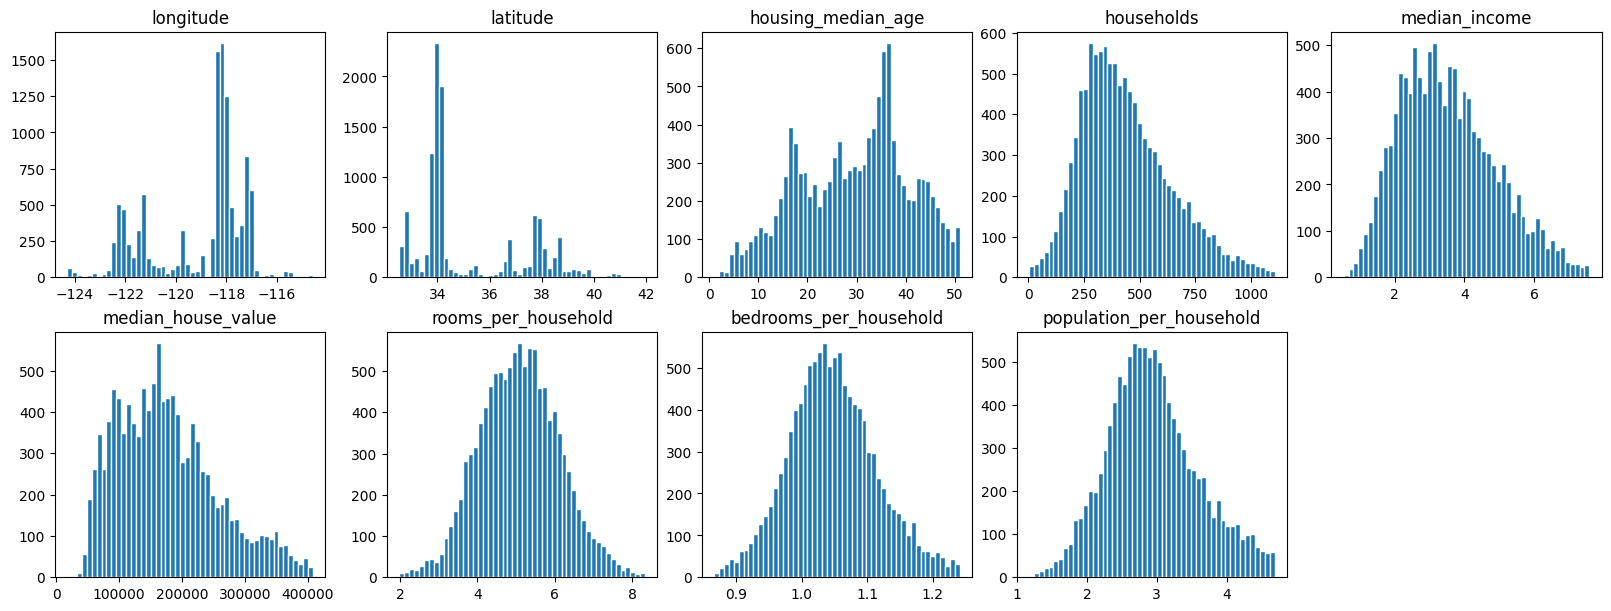

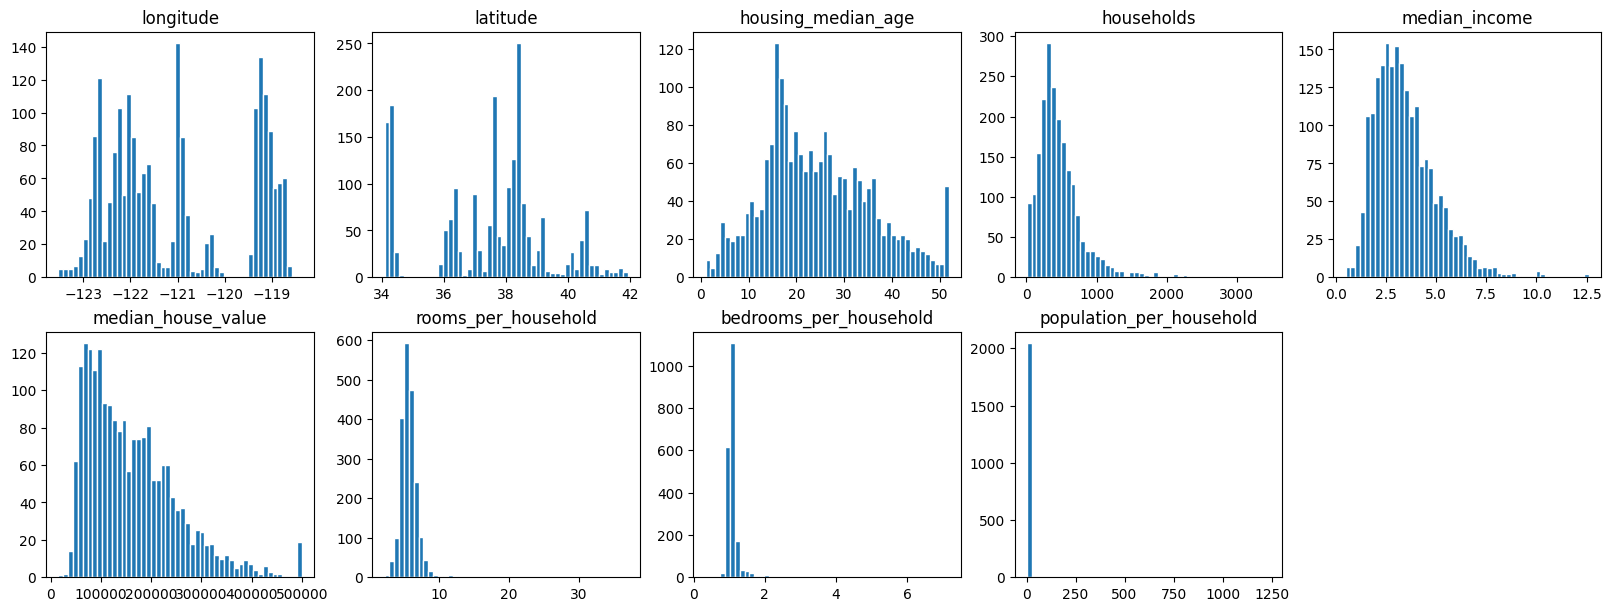

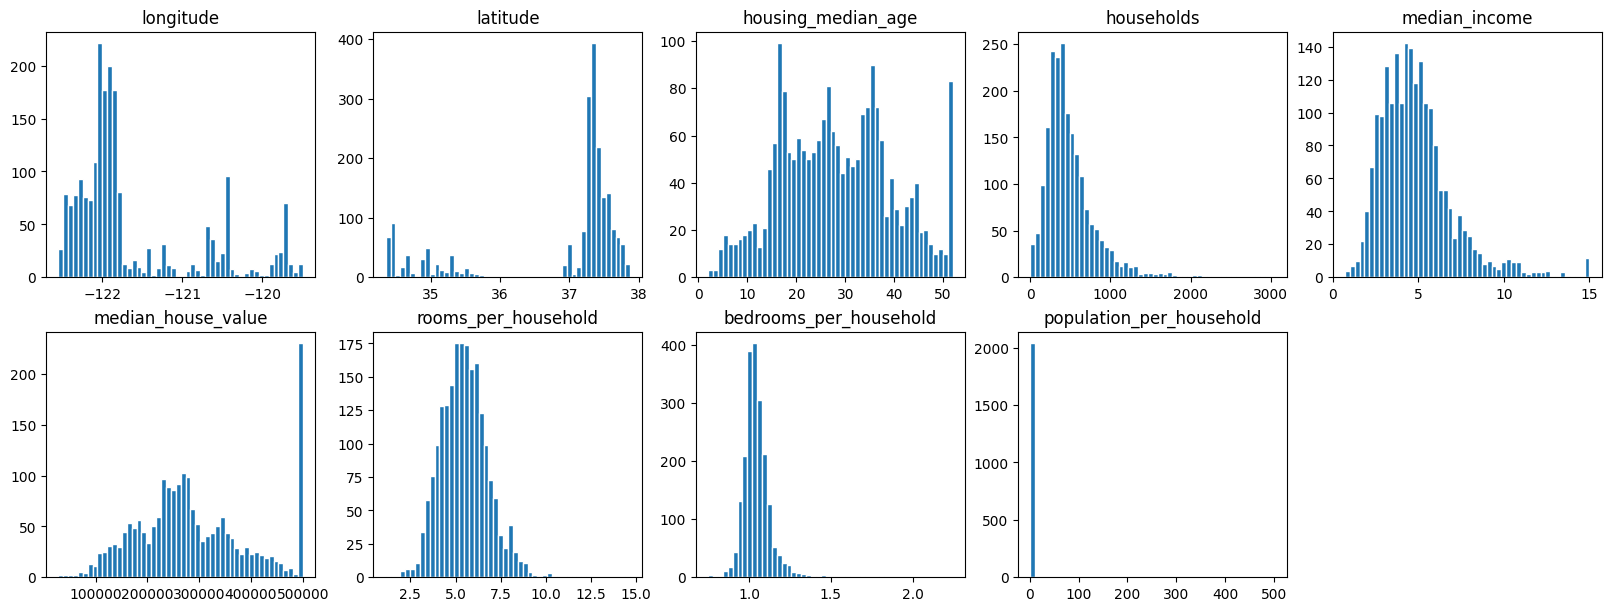

In [31]:
plotBarPlots(train)
plotBarPlots(test)
plotBarPlots(validation)

# TO DO

### Que más hacer con el dataset?
Se pueden probar otros modelos de predicción, como el random forest.

Por otro lado, también se pueden usar otras estrategias de tratamiento de datos: imputación, usar otros valores para 'total_rooms' (en vez de los relativos a 'households', etc.)

# Créditos

Código realizado por los miembros del grupo de IA de Informática to Colme (I2C) durante el segundo cuatrimestre del 2026

-----

Última edición de este cuaderno realizada por Marco Gajón

02/04/2026